To find how sensitive the likelihood ratio is to where the peaks are evaluated.

What is

$\frac{|L(\phi_{c} + \delta \phi_{c}) - L(\phi_{c})|}{L(\phi_{c})}$ as function of $\delta \phi$?

How does adding first order corrections affect this?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pycbc.inference.models.gaussian_noise import GaussianNoise
from pycbc.inference.models.marginalized_gaussian_noise import MarginalizedHMPhase
from pycbc.waveform import get_fd_waveform
from pycbc.detector import Detector
from pycbc.psd.analytical import aLIGOZeroDetHighPower
from pycbc.waveform.utils import apply_fd_time_shift
import scipy

/Users/vikasjadhav/anaconda3/envs/hmnumerical/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
## Helper functions
df = 1/24
psd = aLIGOZeroDetHighPower(length=int((1024/df)+1),
                                                 delta_f = df,
                                                 low_freq_cutoff = 20)

psd_network = { 'hl' :{'H1': psd,'L1': psd},
        'h': {'H1': psd},
         'l': {'L1': psd} }

det_network = {
    'hl' : {'H1': Detector('H1'),'L1': Detector('L1')},
    'h' : {'H1': Detector('H1')},
    'l' : {'L1': Detector('L1')}
}

low_freq_network = {
    'hl' : {'H1': 20,'L1': 20},
    'h' : {'H1':20},
    'l' : {'L1': 20}
}

##Helper functions

def generate_data(network,**params):
    data = {}
    for ifo in det_network[network]:
        hp,hc = get_fd_waveform(delta_f = df,**params)
        fp, fc = det_network[network][ifo].antenna_pattern(params['ra'],
                             params['dec'],
                             params['polarization'],
                             params['tc'])
        dt = det_network[network][ifo].time_delay_from_earth_center(params['ra'],
                                            params['dec'],
                                            params['tc'])
        tshift = dt + params['tc']
        data[ifo] = apply_fd_time_shift(fp*hp + fc*hc,
                                                             tshift)
        data[ifo].resize(len(psd))
    return data

def log_rel_err(log_approx, log_true):
    """
    Calculates absolute relative error between approx and true values
    |approx-true|/true

    """
    delta = log_approx - log_true
    if delta > 0 :
        return np.log10(np.e**(delta)-1)
    if delta < 0 :
        return np.log10(1- np.e**(delta))

def brute_marg(cls_instance,
               param_min,param_max,nsamples):
    
    samples = np.linspace(param_min,
                          param_max,
                          nsamples)
    loglr_samples = np.zeros(len(samples))
    for i in range(len(samples)):
        ##Currently hard coded to marginalise coa_phase
        cls_instance.update(coa_phase=samples[i])
        loglr_samples[i] = cls_instance.loglr
    marg_loglr = scipy.special.logsumexp(loglr_samples) - np.log(nsamples)
    return {'margloglr' : marg_loglr,
            'phi_samples' : samples,
            'loglr_samples' : loglr_samples}

def rvs_marg(cls_instance,
             param_min, param_max, nsamples):
    
    rvs = np.random.rand(nsamples)
    samples = param_min + rvs*(param_max - param_min)
    loglr_samples = np.zeros(nsamples)
    for i in range(nsamples):
        cls_instance.update(coa_phase = samples[i])
        loglr_samples[i] = cls_instance.loglr
    marg_loglr = scipy.special.logsumexp(loglr_samples) - np.log(nsamples)
    return {'margloglr' : marg_loglr,
            'phi_samples' : samples,
            'loglr_samples' : loglr_samples}


def create_static(param):
    static = param.copy()
    _ = static.pop('coa_phase')
    return static

def draw_inj_samples(inj_file, n):
    param_dict = {}
    for p in inj_file.keys():
        param_dict[p] = inj_file[p][n]
    for sp in inj_file.attrs['static_args']:
        param_dict[sp] = inj_file.attrs[sp]
    return param_dict

def lr_surface(phi,cls_instance):
    cls_instance.update(coa_phase=phi)
    return np.e**(cls_instance.loglr)

def peak_loglr(cls_instance,true_phi):
    cls_instance.update(coa_phase = true_phi)
    return cls_instance.loglr

def rescaled_lr_surface(phi,cls_instance,true_phi):
    max_loglr = peak_loglr(cls_instance,true_phi)
    cls_instance.update(coa_phase = phi)
    return np.e**(cls_instance.loglr - max_loglr)
 

#def quad_int(cls_instace,param_min, param_max,true_phi):
#    I = scipy.integrate.quad(rescaled_lr_surface,param_min,param_max,args = (cls_instace,true_phi))
#    logscale = peak_loglr(cls_instace,true_phi)
#    return np.log(I[0]) + logscale - np.log(2*np.pi)

def quad_int(cls_instace,param_min, param_max):
    I = scipy.integrate.quad(lr_surface,param_min,param_max,args = (cls_instace))
    return np.log(I[0]) - np.log(2*np.pi)



In [3]:
inj_file = h5py.File('../../injections.hdf','r')
network = 'h'
variable_params = {'coa_phase'}
test_param = draw_inj_samples(inj_file,1)
test_param['mode_array'] = '22 33'


In [37]:
print(test_param)

{'coa_phase': np.float64(1.8205384945832206), 'dec': np.float64(-1.0895037485407142), 'distance': np.float64(964.2926989443145), 'inclination': np.float64(1.0555663248233589), 'mass1': np.float64(5.9338377211730675), 'mass2': np.float64(47.88691133254745), 'polarization': np.float64(5.074864313861567), 'ra': np.float64(3.381868727895568), 'tc': np.float64(1420877912.5653896), 'approximant': 'IMRPhenomXPHM', 'f_ref': np.float64(20.0), 'f_lower': np.float64(20.0), 'mode_array': '22 33'}


In [33]:
N = 10
dphi = np.logspace(-4,-1,200)
error_loglr = []
error_loglr_cor = []
loglr_atoff = np.zeros(N)
loglr_atoff_cor = np.zeros(N)
dphi_22 = np.zeros(N)
for i in range(N):
    param = draw_inj_samples(inj_file,i)
    param['mode_array'] = '22 33'
    true_phi = param['coa_phase']
    data = generate_data(network,**param)
    e_loglr = np.zeros(len(dphi))
    e_loglr_cor = np.zeros(len(dphi))
    hm_true = MarginalizedHMPhase(variable_params,data=data,
                              low_frequency_cutoff=low_freq_network[network],
                              psds = psd_network[network],
                              static_params = create_static(param),
                              offset=0)
    ## just to get where the 22 peaks are
    hm_true_dom = MarginalizedHMPhase(variable_params,data=data,
                              low_frequency_cutoff=low_freq_network[network],
                              psds = psd_network[network],
                              static_params = create_static(param),
                              offset=0,dominant_mode_peak=True)
    hm_true.update(coa_phase=0)
    hm_true_dom.update(coa_phase=0)
    true_loglr = hm_true.loglr
    hm_true_dom.loglr
    dom_peaks = hm_true_dom.peaks
    dphi_22[i] = np.min(np.abs(dom_peaks-true_phi))
    hm_at_off = MarginalizedHMPhase(variable_params,data=data,
                              low_frequency_cutoff=low_freq_network[network],
                              psds = psd_network[network],
                              static_params = create_static(param),
                              offset=dphi_22[i])
    hm_at_off.update(coa_phase = 0)
    loglr_atoff[i] = log_rel_err(hm_at_off.loglr,true_loglr)
    hm_at_off_cor = MarginalizedHMPhase(variable_params,data=data,
                              low_frequency_cutoff=low_freq_network[network],
                              psds = psd_network[network],
                              static_params = create_static(param),
                              offset=dphi_22[i],first_order_correction=True)
    hm_at_off_cor.update(coa_phase = 0)
    loglr_atoff_cor[i] = log_rel_err(hm_at_off_cor.loglr,true_loglr)
    for j in range(len(dphi)):
        hm_offset = MarginalizedHMPhase(variable_params,data=data,
                              low_frequency_cutoff=low_freq_network[network],
                              psds = psd_network[network],
                              static_params = create_static(param),
                              offset=dphi[j])
        hm_offset_cor = MarginalizedHMPhase(variable_params,data=data,
                              low_frequency_cutoff=low_freq_network[network],
                              psds = psd_network[network],
                              static_params = create_static(param),
                              offset=dphi[j],first_order_correction=True)
        hm_offset.update(coa_phase = 0)
        hm_offset_cor.update(coa_phase = 0)
        off_loglr = hm_offset.loglr
        off_loglr_cor = hm_offset_cor.loglr
        e_loglr[j] = log_rel_err(off_loglr,true_loglr)
        e_loglr_cor[j] = log_rel_err(off_loglr_cor,true_loglr)
    error_loglr.append(e_loglr)
    error_loglr_cor.append(e_loglr_cor)

using analytic approximation
0.0003837919794023037
using analytic approximation
0.0002825420815497637
using analytic approximation
0.00031700008548796177
using analytic approximation
0.0003234578762203455
using analytic approximation
0.00031991605646908283
using analytic approximation
0.00030270894058048725
using analytic approximation
0.0002993340604007244
using analytic approximation
0.00030633294954895973
using analytic approximation
0.00030216691084206104
using analytic approximation
0.00030783400870859623
using analytic approximation
0.0003055410925298929
using analytic approximation
0.0003023340832442045
using analytic approximation
0.000332291005179286
using analytic approximation
0.0003328749444335699
using analytic approximation
0.00029941718094050884
using analytic approximation
0.00031687505543231964
using analytic approximation
0.0002955410163849592
using analytic approximation
0.00030395807698369026
using analytic approximation
0.0003459579311311245
using analytic approxim

In [34]:
print(error_loglr[0])

[-5.4446327  -5.41512375 -5.38559379 -5.35604351 -5.32647354 -5.2968845
 -5.267277   -5.23765161 -5.20800891 -5.17834946 -5.14867377 -5.11898239
 -5.08927581 -5.05955451 -5.02981898 -5.00006968 -4.97030705 -4.94053152
 -4.91074351 -4.88094344 -4.85113169 -4.82130864 -4.79147468 -4.76163015
 -4.7317754  -4.70191077 -4.67203659 -4.64215318 -4.61226083 -4.58235985
 -4.55245053 -4.52253314 -4.49260795 -4.46267522 -4.43273521 -4.40278817
 -4.37283432 -4.34287391 -4.31290715 -4.28293426 -4.25295546 -4.22297093
 -4.19298089 -4.16298551 -4.13298499 -4.10297951 -4.07296924 -4.04295435
 -4.012935   -3.98291135 -3.95288356 -3.92285178 -3.89281615 -3.86277682
 -3.83273392 -3.8026876  -3.77263798 -3.74258518 -3.71252935 -3.68247059
 -3.65240903 -3.62234478 -3.59227797 -3.5622087  -3.53213708 -3.50206323
 -3.47198725 -3.44190925 -3.41182933 -3.3817476  -3.35166417 -3.32157913
 -3.29149259 -3.26140466 -3.23131543 -3.20122502 -3.17113352 -3.14104105
 -3.11094771 -3.0808536  -3.05075885 -3.02066357 -2.

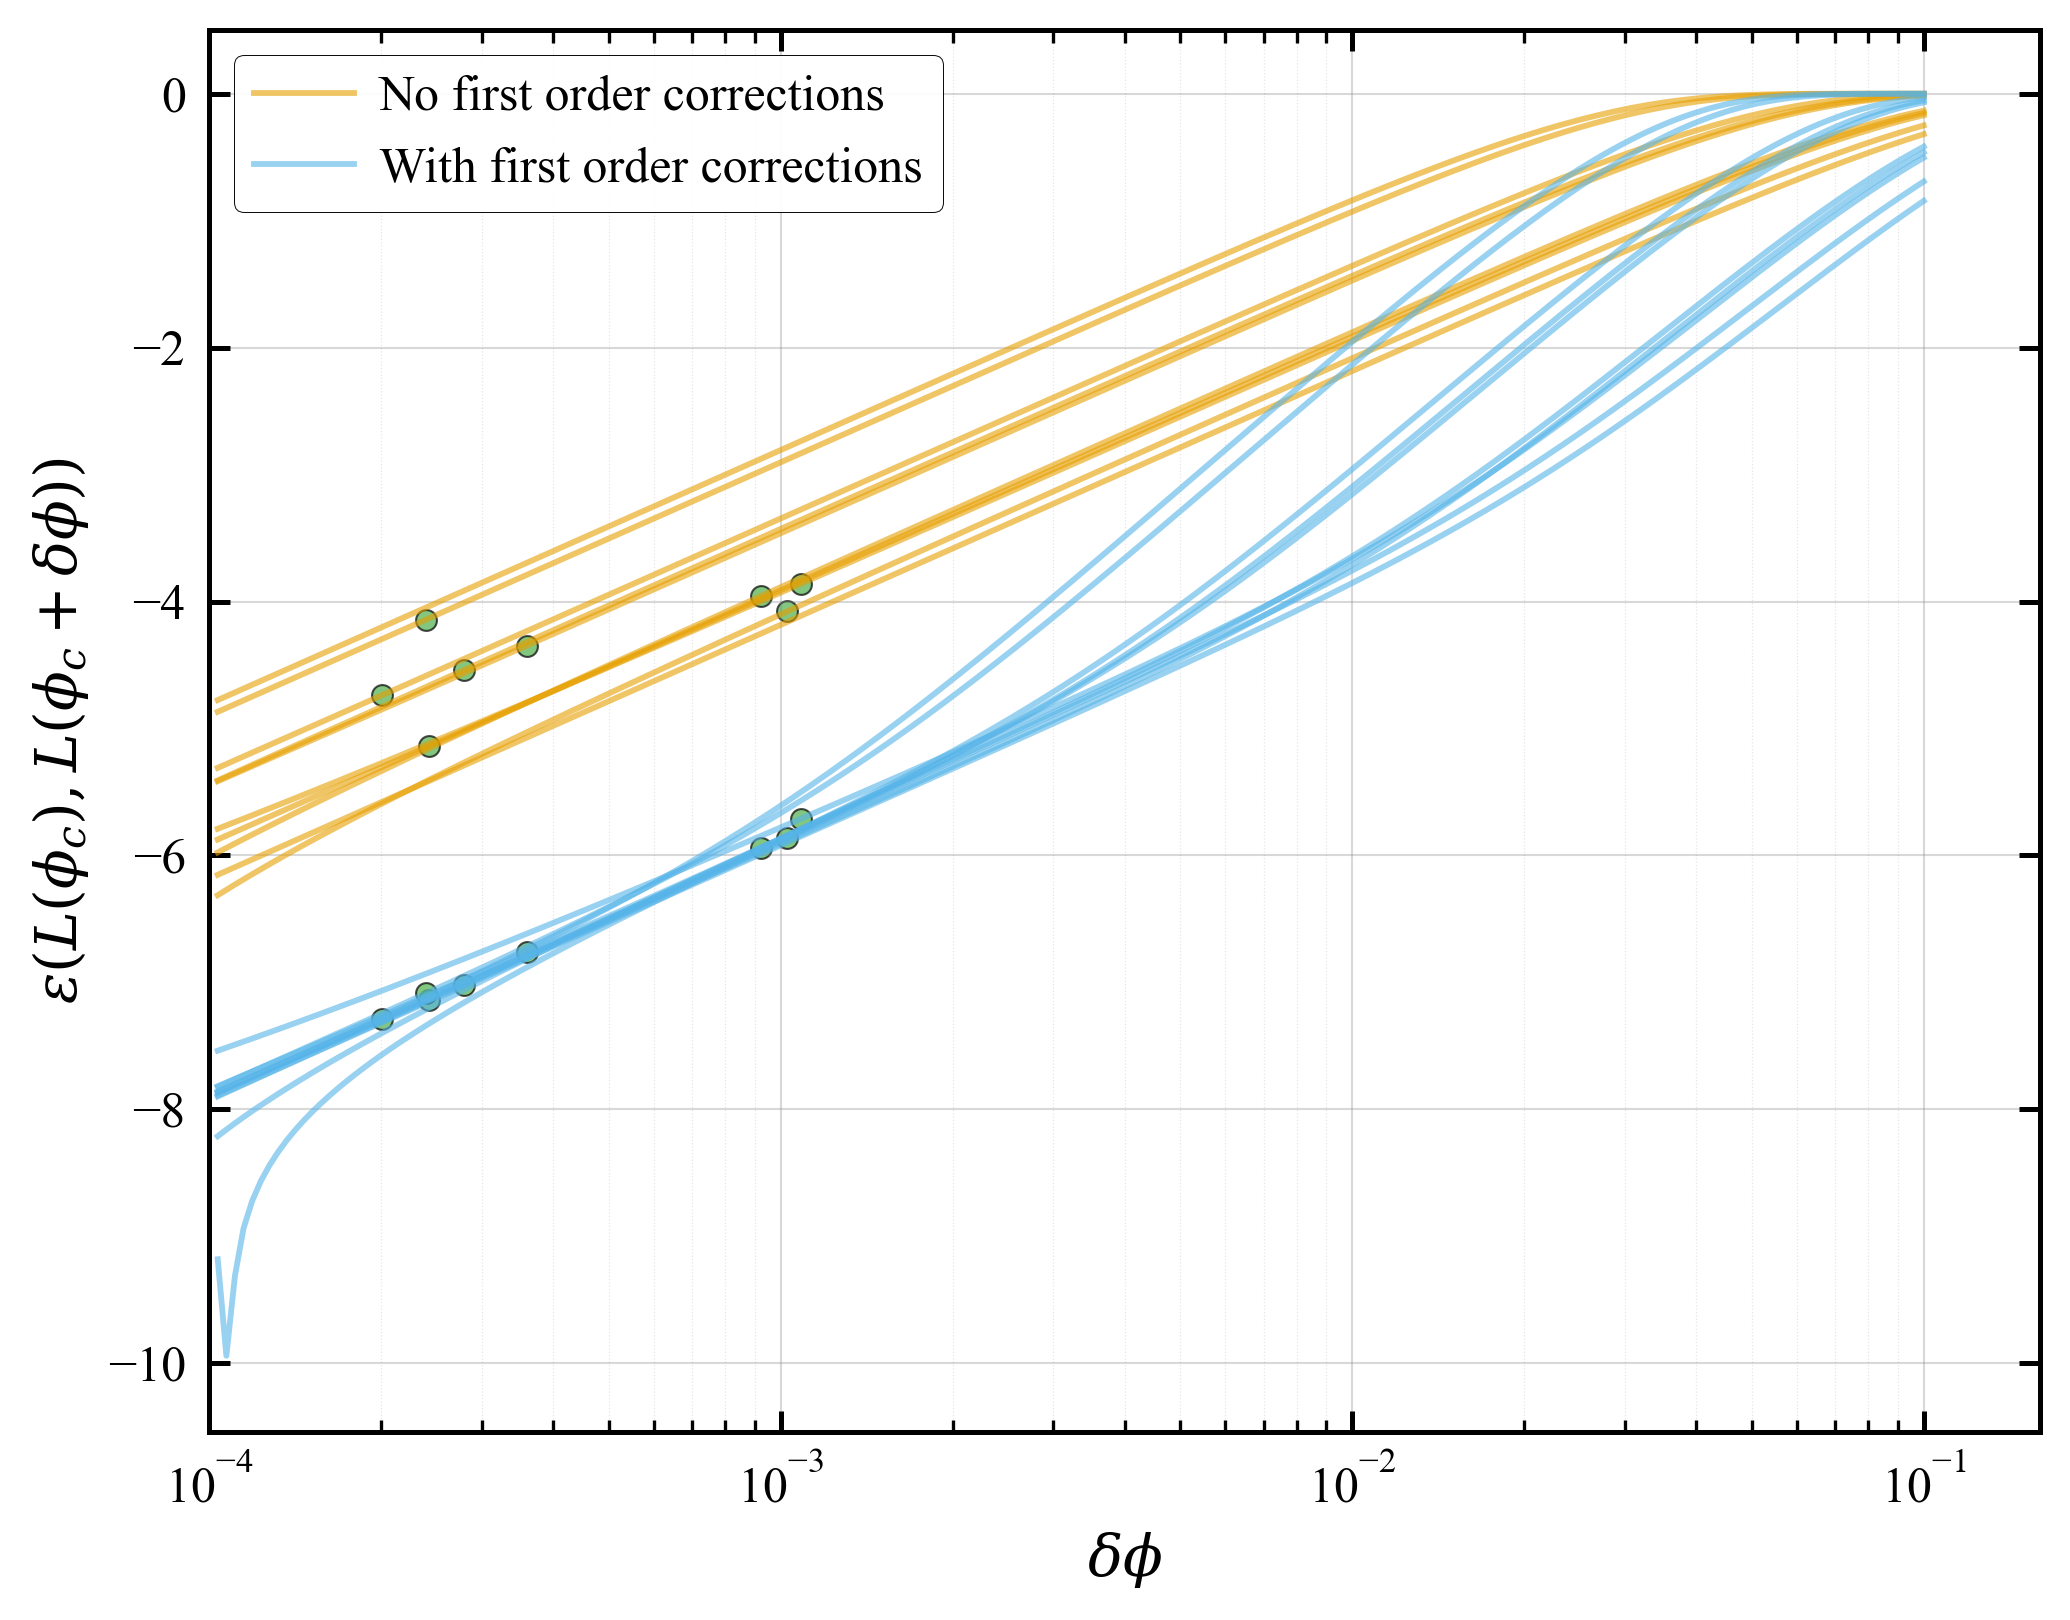

In [39]:
import matplotlib as mpl

# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2
mpl.rcParams['xtick.minor.width'] = 0.8
mpl.rcParams['ytick.minor.width'] = 0.8
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3

# Create figure with appropriate size for journal (single column ~3.5", double column ~7")
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)

colors = ['#E69F00', '#56B4E9']  
markers = ['o', 's']
size = 25

ax.scatter(
    dphi_22, loglr_atoff,
    s = size, alpha=0.7,
    color = '#4DAF4A',
    marker='o',
    edgecolors='black',
    linewidths=0.5
)

ax.scatter(
    dphi_22, loglr_atoff_cor,
    s = size, alpha=0.7,
    color = '#4DAF4A',
    marker='o',
    edgecolors='black',
    linewidths=0.5
)

for i, arr in enumerate(error_loglr):
    ax.plot(dphi[1:], arr[1:], label='No first order corrections' if i == 0 else '', color='#E69F00', alpha=0.6)

for i, arr in enumerate(error_loglr_cor):
    ax.plot(dphi[1:], arr[1:], label='With first order corrections' if i == 0 else '', color='#56B4E9', alpha=0.6)

ax.set_xscale('log')
ax.set_xlim(left=1e-4)
#ax.set_yscale('log')
ax.set_ylabel(r'$\epsilon(L(\phi_{c}),L(\phi_{c}+\delta \phi))$', fontsize=14)
ax.set_xlabel(r'$\delta \phi$', fontsize=14)

ax.tick_params(labelsize=12, which='both', direction='in', top=True, right=True)

ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3, color='gray')
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.2, color='gray')

ax.legend(loc='best', frameon=True, framealpha=0.95, 
          edgecolor='black', fontsize=12, 
          markerscale=1.5, handletextpad=0.5)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()

plt.show()

# fig.savefig('figure.pdf', dpi=300, bbox_inches='tight', format='pdf')
fig.savefig('first_order_corrections.png', dpi=300, bbox_inches='tight')